<a href="https://colab.research.google.com/github/Rakesh114166/Rakesh-dock/blob/main/third_attempt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title CELL 1: System Software Compilation { display-mode: "form" }
#@markdown Run this cell to completely purge broken updates and deploy the stable wheel architecture.

import sys
import subprocess

print("[-] Purging all broken and cached package configurations...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "openbabel", "openbabel-wheel", "plip"], check=True)

print("[-] Updating system registries & installing static system utilities...")
subprocess.run(["sudo", "apt-get", "update", "-qq"], check=True)
subprocess.run(["sudo", "apt-get", "install", "-y", "-qq", "openbabel"], check=True)

print("[-] Deploying static binary for AutoDock Vina v1.2.5...")
vina_url = "https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64"
subprocess.run(["wget", "-q", vina_url, "-O", "/usr/local/bin/vina"], check=True)
subprocess.run(["chmod", "+x", "/usr/local/bin/vina"], check=True)

print("[-] Deploying stable pre-compiled OpenBabel wheels...")
# Bypasses the broken source distribution packages completely
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "openbabel-wheel"], check=True)

print("[-] Installing core chemical informatics stack (RDKit, py3Dmol, pandas)...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rdkit", "py3Dmol", "pandas"], check=True)

print("[-] Deploying interaction profiler engine (PLIP) with dependency isolation...")
# --no-deps prevents pip from overriding or breaking our clean openbabel-wheel installation
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "plip", "--no-deps"], check=True)

print("\n[+] SYSTEM CONFIGURATION COMPLETE")
print(f"    ↳ OpenBabel CLI : {subprocess.getoutput('obabel -V').strip()}")
print(f"    ↳ AutoDock Vina : {subprocess.getoutput('vina --version').splitlines()[0]}")

[-] Purging all broken and cached package configurations...
[-] Updating system registries & installing static system utilities...
[-] Deploying static binary for AutoDock Vina v1.2.5...
[-] Deploying stable pre-compiled OpenBabel wheels...
[-] Installing core chemical informatics stack (RDKit, py3Dmol, pandas)...
[-] Deploying interaction profiler engine (PLIP) with dependency isolation...

[+] SYSTEM CONFIGURATION COMPLETE
    ↳ OpenBabel CLI : Open Babel 3.1.0 -- Feb 17 2026 -- 06:47:59
    ↳ AutoDock Vina : AutoDock Vina v1.2.5


In [2]:
#@title CELL 2: Core Module Initialization { display-mode: "form" }
#@markdown Initializes standard, specialized, and structural module dependencies into the namespace.

import os
import sys
import subprocess

print("[-] Verifying core ecosystem stability and binding paths...")

try:
    import pandas as pd
    import py3Dmol
    import rdkit
    from rdkit import Chem
    from rdkit.Chem import AllChem
    import plip
    from plip.structure.preparation import PDBComplex

    print("\n[+] CORE ENVIRONMENT INITIALIZED SUCCESSFULLY")
    print(f"    ↳ Interpreter Platform   : Python {sys.version.split()[0]}")
    print(f"    ↳ Pandas Data Matrix API : v{pd.__version__}")
    print(f"    ↳ RDKit Core Engine      : v{rdkit.__version__}")
    print(f"    ↳ PLIP Profiler Binding  : Active and stable")

except Exception as e:
    print(f"\n[!] Initialization Failure: {e}")
    print("    ↳ Action Required: Go to the top menu, click 'Runtime' -> 'Restart Session', then re-run CELL 1 and CELL 2.")

[-] Verifying core ecosystem stability and binding paths...

[+] CORE ENVIRONMENT INITIALIZED SUCCESSFULLY
    ↳ Interpreter Platform   : Python 3.12.13
    ↳ Pandas Data Matrix API : v2.2.2
    ↳ RDKit Core Engine      : v2026.03.2
    ↳ PLIP Profiler Binding  : Active and stable


In [3]:
#@title CELL 3: Project Directory Layout Generator { display-mode: "form" }
#@markdown Enter a `< Job Name >` without spaces to establish your workspace directories.

Job_name = "TGFb_1PY5_VS" #@param {type:"string"}

import os

# Strict input verification matching the original layout rules
assert not Job_name == "", "Do not leave this blank."
assert not any(c == "/" or c == "." or c == " " for c in Job_name), "Disallowed characters detected in your Job Name."

print(f"[-] Initializing project workspace root for simulation tracking: '{Job_name}'")

# Map out absolute directory paths matching your workflow chart layout
BASE_DIR = os.getcwd()
WRK_DIR  = os.path.join(BASE_DIR, Job_name)
PRT_FLD  = os.path.join(WRK_DIR, "PROTEIN")
LIG_FLD  = os.path.join(WRK_DIR, "LIGAND")
EXP_FLD  = os.path.join(WRK_DIR, "EXPERIMENTAL")
DCK_FLD  = os.path.join(WRK_DIR, "DOCKING")
INT_FLD  = os.path.join(WRK_DIR, "INTERACTION")

folders = [WRK_DIR, PRT_FLD, LIG_FLD, EXP_FLD, DCK_FLD, INT_FLD]

for f in folders:
    if os.path.exists(f):
        print(f"    [!] Notice: Node element folder already exists -> {os.path.basename(f)}")
    else:
        os.makedirs(f, exist_ok=True)
        print(f"    [->] Successfully Generated Directory Folder Node: {f}")

# Inject path mappings into environmental variables for clean cross-cell data handshake
os.environ['WRK_DIR'] = WRK_DIR
os.environ['PRT_FLD'] = PRT_FLD
os.environ['LIG_FLD'] = LIG_FLD
os.environ['EXP_FLD'] = EXP_FLD
os.environ['DCK_FLD'] = DCK_FLD
os.environ['INT_FLD'] = INT_FLD

print("\n[+] WORKSPACE PATHWAYS ASSIGNED SUCCESSFULLY")
print(f"    ↳ Active Project Root Directory: {os.environ['WRK_DIR']}")

[-] Initializing project workspace root for simulation tracking: 'TGFb_1PY5_VS'
    [->] Successfully Generated Directory Folder Node: /content/TGFb_1PY5_VS
    [->] Successfully Generated Directory Folder Node: /content/TGFb_1PY5_VS/PROTEIN
    [->] Successfully Generated Directory Folder Node: /content/TGFb_1PY5_VS/LIGAND
    [->] Successfully Generated Directory Folder Node: /content/TGFb_1PY5_VS/EXPERIMENTAL
    [->] Successfully Generated Directory Folder Node: /content/TGFb_1PY5_VS/DOCKING
    [->] Successfully Generated Directory Folder Node: /content/TGFb_1PY5_VS/INTERACTION

[+] WORKSPACE PATHWAYS ASSIGNED SUCCESSFULLY
    ↳ Active Project Root Directory: /content/TGFb_1PY5_VS


In [4]:
#@title CELL 4: Receptor Chain Isolation & Parameterization { display-mode: "form" }
#@markdown Download target PDB structures, isolate desired protein chains, strip water matrices, and parameterize to PDBQT.

PDB_ID = "1PY5" #@param {type:"string"}
CHAIN_ID = "A" #@param {type:"string"}

import os
import urllib.request
import subprocess
import py3Dmol

# Fetch target directories from the environment variables set in Cell 3
PRT_FLD = os.environ.get('PRT_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not PRT_FLD or not DCK_FLD:
    raise ValueError("Workspace directories not detected. Please run Cell 3 first to generate paths.")

# Dynamically construct filenames to match your workflow schema exactly
base_name = f"{PDB_ID.upper()}_prot_{CHAIN_ID.upper()}"
raw_pdb_path = os.path.join(PRT_FLD, f"{PDB_ID.lower()}.pdb")
clean_pdb_path = os.path.join(PRT_FLD, f"{base_name}.pdb")
docking_pdb_copy = os.path.join(DCK_FLD, f"{base_name}.pdb")
receptor_pdbqt = os.path.join(DCK_FLD, f"{base_name}.pdbqt")

print(f"[-] Fetching crystal structure '{PDB_ID.upper()}' securely from RCSB PDB Repository...")
url = f"https://files.rcsb.org/download/{PDB_ID.upper()}.pdb"
try:
    urllib.request.urlretrieve(url, raw_pdb_path)
    print(f"    ↳ PDB downloaded: {PDB_ID.lower()}.pdb ==> PROTEIN folder")
except Exception as e:
    raise RuntimeError(f"Network error: Unable to retrieve PDB file {PDB_ID}. Details: {e}")

print(f"[-] Extracting protein: Isolating Chain '{CHAIN_ID}' and clearing water matrices...")
atom_count = 0

with open(raw_pdb_path, 'r') as infile, open(clean_pdb_path, 'w') as outfile:
    for line in infile:
        # Capture standard amino acid backbone rows (ATOM)
        if line.startswith("ATOM  "):
            line_chain = line[21].strip()
            # If a specific chain is required, match it; otherwise extract all chains
            if line_chain == CHAIN_ID or not CHAIN_ID:
                outfile.write(line)
                atom_count += 1
        # Maintain core structural break coordinates
        elif line.startswith("TER   ") or line.startswith("ENDMDL"):
            if atom_count > 0:  # Only write breaks if we have already isolated atoms for this frame
                outfile.write(line)

if atom_count == 0:
    raise ValueError(f"Target isolation failed: No ATOM records found matching Chain '{CHAIN_ID}'.")
print(f"    ↳ Protein extracted: {PDB_ID.lower()}.pdb --> {base_name}.pdb")

# Sync clean PDB file over to the DOCKING folder to match original tutorial architecture
with open(clean_pdb_path, 'r') as src, open(docking_pdb_copy, 'w') as dst:
    dst.write(src.read())

print("[-] Running structural parameterization and Gasteiger charge assignment via OpenBabel...")
# -xr builds a rigid receptor by preserving atom records and blocking bond rotations
cmd = ["obabel", clean_pdb_path, "-O", receptor_pdbqt, "-xr", "--partialcharge", "gasteiger"]
subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print(f"    ↳ Protein parameterized: {base_name}.pdb --> {base_name}.pdbqt")
print(f"    ↳ {base_name}.pdb ==> DOCKING folder")
print(f"    ↳ {base_name}.pdbqt ==> DOCKING folder")

# Render the isolated receptor backbone interactively
print("\n[-] Displaying 3D protein macromolecular architecture...")
view = py3Dmol.view(width=650, height=450)
with open(clean_pdb_path, 'r') as f:
    view.addModel(f.read(), 'pdb')
view.setStyle({'cartoon': {'color': 'spectrum'}})
view.zoomTo()
view.show()

[-] Fetching crystal structure '1PY5' securely from RCSB PDB Repository...
    ↳ PDB downloaded: 1py5.pdb ==> PROTEIN folder
[-] Extracting protein: Isolating Chain 'A' and clearing water matrices...
    ↳ Protein extracted: 1py5.pdb --> 1PY5_prot_A.pdb
[-] Running structural parameterization and Gasteiger charge assignment via OpenBabel...
    ↳ Protein parameterized: 1PY5_prot_A.pdb --> 1PY5_prot_A.pdbqt
    ↳ 1PY5_prot_A.pdb ==> DOCKING folder
    ↳ 1PY5_prot_A.pdbqt ==> DOCKING folder

[-] Displaying 3D protein macromolecular architecture...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
#@title CELL 5: Experimental Native Control Extraction { display-mode: "form" }
#@markdown Extract co-crystallized native ligands from the raw crystal structure to serve as your experimental validation control.

Keyword = "PY1" #@param {type:"string"}

import os
import subprocess
import shutil
import glob
import py3Dmol

# Retrieve absolute directory trees from the environment variables set in Cell 3
PRT_FLD = os.environ.get('PRT_FLD')
EXP_FLD = os.environ.get('EXP_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not all([PRT_FLD, EXP_FLD, DCK_FLD]):
    raise ValueError("Workspace directories missing. Please re-run Cell 3 first.")

# Discover the raw protein PDB structure downloaded during Cell 4 execution
pdb_candidates = [f for f in os.listdir(PRT_FLD) if f.endswith('.pdb') and not '_prot_' in f]
if not pdb_candidates:
    raise FileNotFoundError("Raw reference PDB file not discovered inside PROTEIN folder. Run Cell 4 first.")

raw_pdb_target = os.path.join(PRT_FLD, pdb_candidates[0])

# Match file variables exactly to your original tutorial schema rules
Elig_pdb = f"{Keyword.upper()}.pdb"
Elig_pdbqt = f"{Keyword.upper()}.pdbqt"

Elig_pdb_Efile = os.path.join(EXP_FLD, Elig_pdb)
Elig_pdbqt_Efile = os.path.join(EXP_FLD, Elig_pdbqt)

Elig_pdb_Dfile = os.path.join(DCK_FLD, Elig_pdb)
Elig_pdbqt_Dfile = os.path.join(DCK_FLD, Elig_pdbqt)

# --- AUTO-PURGE: Clean old legacy instances out of the folder to keep paths pure ---
for pattern in [f"*{Keyword.upper()}*", "*NAG*", "*CONTROL*"]:
    for old_file in glob.glob(os.path.join(EXP_FLD, pattern)) + glob.glob(os.path.join(DCK_FLD, pattern)):
        try:
            os.remove(old_file)
        except:
            pass

print(f"[-] Scanning structural coordinates for heteroatom records matching: {Keyword.upper()}")
match_confirmed = False

with open(raw_pdb_target, 'r') as infile, open(Elig_pdb_Efile, 'w') as outfile:
    for line in infile:
        # Isolate HETATM and structural binding records matching the control drug key
        if (line.startswith("HETATM") or line.startswith("CONECT")) and Keyword.upper() in line:
            outfile.write(line)
            match_confirmed = True

if not match_confirmed or os.path.getsize(Elig_pdb_Efile) == 0:
    print(f"[!] Warning: No structural coordinates found matching code '{Keyword.upper()}'.")
    print("    ↳ Action required: Double check your PDB ID or manually enter the exact 3-letter code.")
else:
    print(f"[+] Experimental ligand extracted: {os.path.basename(raw_pdb_target)} --> {Elig_pdb}")
    print("[-] Generating explicit protonation maps and calculating Gasteiger partial charges via OpenBabel...")

    # Add explicit hydrogens (-h) at physiological parameter levels and calculate partial charges
    cmd = ["obabel", Elig_pdb_Efile, "-O", Elig_pdbqt_Efile, "-h", "--partialcharge", "gasteiger"]
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # Synchronize structural profiles over to the DOCKING directory to match video architecture
    shutil.copy(Elig_pdb_Efile, Elig_pdb_Dfile)
    shutil.copy(Elig_pdbqt_Efile, Elig_pdbqt_Dfile)

    print(f"[+] {Elig_pdb} ==> EXPERIMENTAL folder & DOCKING folder")
    print(f"[+] {Elig_pdbqt} ==> EXPERIMENTAL folder & DOCKING folder")

    # Render the isolated reference drug molecule interactively
    print("\n[-] Displaying 3D experimental control ligand structure...")
    view = py3Dmol.view(width=650, height=450)
    with open(Elig_pdb_Efile, 'r') as f:
        view.addModel(f.read(), 'pdb')
    view.setStyle({'stick': {'colorscheme': 'cyanCarbon'}})
    view.zoomTo()
    view.show()

[-] Scanning structural coordinates for heteroatom records matching: PY1
[+] Experimental ligand extracted: 1py5.pdb --> PY1.pdb
[-] Generating explicit protonation maps and calculating Gasteiger partial charges via OpenBabel...
[+] PY1.pdb ==> EXPERIMENTAL folder & DOCKING folder
[+] PY1.pdbqt ==> EXPERIMENTAL folder & DOCKING folder

[-] Displaying 3D experimental control ligand structure...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
#@title CELL 6: CSV High-Throughput Ligand Preparation { display-mode: "form" }
#@markdown Batch-process an uploaded spreadsheet of compounds from SMILES to optimized 3D PDBQT structures.

Compound_library = "compound_1.csv" #@param {type:"string"}
Select_force_field = "UFF" #@param ["GAFF", "Ghemical", "MMFF94", "MMFF94s", "UFF"]
Max_minimization_steps = 10000 #@param {type:"slider", min:1000, max:20000, step:1000}
View_ligand = "NARINGENIN" #@param {type:"string"}

import os
import shutil
import subprocess
import pandas as pd
import py3Dmol

# Retrieve absolute directory trees from the environment variables set in Cell 3
WRK_DIR = os.environ.get('WRK_DIR')
LIG_FLD = os.environ.get('LIG_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not all([WRK_DIR, LIG_FLD, DCK_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

CL_csv_Lfile = os.path.join(LIG_FLD, Compound_library)

# --- AUTOMATED TEMPLATE GENERATOR ---
if not os.path.exists(CL_csv_Lfile):
    print(f"[!] Alert: Spreadsheet template '{Compound_library}' not detected inside LIGAND folder.")
    print("    ↳ Generating a fresh screening library containing PY1 (control), Naringenin, and Esculin...")
    sample_payload = {
        "ID": ["PY1", "NARINGENIN", "ESCULIN"],
        "SMILES": [
            "C1=CC=C2C(=C1)C(=CC=N2)C3=CNN=C3C4=CC=CC=N4", # PY1 (True 1PY5 Control Drug)
            "O=C1CC(C2=CC=C(O)C=C2)OC3=CC(O)=CC(O)=C13",     # Naringenin
            "O=C1C=C(O[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)C3=C(O)C=CC(=C3O1)" # Esculin
        ]
    }
    pd.DataFrame(sample_payload).to_csv(CL_csv_Lfile, index=False)

# Read library using the exact string column indexing from your video layout
try:
    ligDF = pd.read_csv(CL_csv_Lfile, dtype=str)
    lig_IDs = tuple(ligDF["ID"].str.strip().str.upper())
    lig_SMILES = tuple(ligDF["SMILES"].str.strip())
except Exception as e:
    raise RuntimeError(f"Failed to read chemical library layout matrix: {e}")

print(f"[+] Loaded chemical target library spreadsheet. Processing {len(lig_IDs)} compounds...")

# Step 1: Write raw .smi structural seed rows to disk
for N, ID in enumerate(lig_IDs):
    smi_file = os.path.join(LIG_FLD, f"{ID}.smi")
    with open(smi_file, "w") as o:
        o.write(lig_SMILES[N])

print(f"    ↳ + {len(lig_IDs)} ligand.smi ==> LIGAND folder")

# Step 2: High-Performance 3D Coordinate Mapping & Charge Parameterization Loop
for N, ID in enumerate(lig_IDs):
    smi_file = os.path.join(LIG_FLD, f"{ID}.smi")
    mol2_file = os.path.join(WRK_DIR, f"{ID}.mol2")
    final_mol2_path = os.path.join(LIG_FLD, f"{ID}.mol2")

    # Establish separate subfolders for each ligand inside DOCKING
    lig_Dfld = os.path.join(DCK_FLD, ID)
    os.makedirs(lig_Dfld, exist_ok=True)
    pdbqt_file = os.path.join(lig_Dfld, f"{ID}.pdbqt")

    # Run structural minimization macro-loop via modern OpenBabel CLI
    # Generates lowest-energy 3D conformations using your chosen force field selection
    cmd_minimize = [
        "obabel", smi_file, "-O", mol2_file,
        "--gen3d", "--best", "--canonical",
        "--minimize", "--ff", Select_force_field,
        "--steps", str(Max_minimization_steps)
    ]
    subprocess.run(cmd_minimize, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # Move minimized .mol2 transition file to LIGAND folder to preserve workspace architecture
    if os.path.exists(mol2_file):
        shutil.move(mol2_file, final_mol2_path)

    # Parameterize .mol2 structure to target .pdbqt docking profile with Gasteiger charges at pH 7.4
    cmd_parameterize = [
        "obabel", final_mol2_path, "-O", pdbqt_file,
        "-ph", "7.4", "--partialcharge", "gasteiger"
    ]
    subprocess.run(cmd_parameterize, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print(f"    ↳ + {len(lig_IDs)} ligand.mol2 ==> LIGAND folder")
print(f"    ↳ + {len(lig_IDs)} ligand.pdbqt ==> DOCKING folder subdirectories")
print(f"\n[+] HIGH-THROUGHPUT LIGAND PREPARATION COMPLETE USING FORCE FIELD: {Select_force_field}")

# Step 3: Interactive 3D Conformer Viewer Panel
target_view_mol2 = os.path.join(LIG_FLD, f"{View_ligand.strip().upper()}.mol2")

if os.path.exists(target_view_mol2):
    print(f"\n[-] Displaying 3D optimized chemical conformation for: {View_ligand.upper()}")
    view = py3Dmol.view(width=650, height=450)
    with open(target_view_mol2, 'r') as f:
        view.addModel(f.read(), 'mol2')
    view.setStyle({'stick': {'colorscheme': 'greenCarbon'}})
    view.zoomTo()
    view.show()
else:
    print(f"\n[!] View Alert: Cannot display 3D structure for '{View_ligand.upper()}'. ID not found in library.")

[!] Alert: Spreadsheet template 'compound_1.csv' not detected inside LIGAND folder.
    ↳ Generating a fresh screening library containing PY1 (control), Naringenin, and Esculin...
[+] Loaded chemical target library spreadsheet. Processing 3 compounds...
    ↳ + 3 ligand.smi ==> LIGAND folder
    ↳ + 3 ligand.mol2 ==> LIGAND folder
    ↳ + 3 ligand.pdbqt ==> DOCKING folder subdirectories

[+] HIGH-THROUGHPUT LIGAND PREPARATION COMPLETE USING FORCE FIELD: UFF

[-] Displaying 3D optimized chemical conformation for: NARINGENIN


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
#@title CELL 7: Place Grid Box at Binding Site { display-mode: "form" }
#@markdown Establish the grid search box parameters over the target kinase binding pocket.

Focus_residues = "" #@param {type:"string"}
Method = "LaBOX" #@param ["LaBOX", "eBoxSize", "eBoxSize-modified", "Autodock-Grid", "manual"]

#@markdown --- Manual Mode Adjustments (Active only if Method is set to 'manual') ---
X = 0.0 #@param {type:"slider", min:-100, max:100, step:0.1}
Y = 0.0 #@param {type:"slider", min:-100, max:100, step:0.1}
Z = 0.0 #@param {type:"slider", min:-100, max:100, step:0.1}
Width = 20.0 #@param {type:"slider", min:10, max:40, step:0.5}
Height = 20.0 #@param {type:"slider", min:10, max:40, step:0.5}
Depth = 20.0 #@param {type:"slider", min:10, max:40, step:0.5}

import os
import math

# Retrieve absolute directory trees from environmental memory
DCK_FLD = os.environ.get('DCK_FLD')
if not DCK_FLD:
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

# Locate the experimental control ligand PDB generated in Cell 5
pdb_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdb') and not '_prot_' in f]
if not pdb_candidates and Method != "manual":
    raise FileNotFoundError(f"Reference control PDB file not found in DOCKING folder. Please run Cell 5 first.")

cx, cy, cz = X, Y, Z
sx, sy, sz = Width, Height, Depth

if Method != "manual":
    control_path = os.path.join(DCK_FLD, pdb_candidates[0])
    print(f"[-] Parsing coordinates from reference control file: {os.path.basename(control_path)}")

    x_coords, y_coords, z_coords = [], [], []
    with open(control_path, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                try:
                    x_coords.append(float(line[30:38].strip()))
                    y_coords.append(float(line[38:46].strip()))
                    z_coords.append(float(line[46:54].strip()))
                except ValueError:
                    continue

    if not x_coords:
        print("[!] Warning: Reference file contains no atomic coordinates. Falling back to manual slider options.")
        Method = "manual"
    else:
        # Calculate coordinate extrema and centroids
        min_x, max_x = min(x_coords), max(x_coords)
        min_y, max_y = min(y_coords), max(y_coords)
        min_z, max_z = min(z_coords), max(z_coords)

        mean_x = sum(x_coords) / len(x_coords)
        mean_y = sum(y_coords) / len(y_coords)
        mean_z = sum(z_coords) / len(z_coords)

        # 1. LaBOX Method: Bounding envelope based on absolute coordinate max/min thresholds
        if Method == "LaBOX":
            cx = round((max_x + min_x) / 2, 3)
            cy = round((max_y + min_y) / 2, 3)
            cz = round((max_z + min_z) / 2, 3)
            # Add a baseline 4.5 Angstrom buffer space to prevent pocket clipping
            sx = round((max_x - min_x) + 4.5, 1)
            sy = round((max_y - min_y) + 4.5, 1)
            sz = round((max_z - min_z) + 4.5, 1)

        # 2. eBoxSize Methods: Frame optimization derived from the ligand's radius of gyration
        elif Method in ["eBoxSize", "eBoxSize-modified"]:
            cx = round(mean_x, 3)
            cy = round(mean_y, 3)
            cz = round(mean_z, 3)

            # Compute the structural radius of gyration (Rg)
            sq_distances = [(x - mean_x)**2 + (y - mean_y)**2 + (z - mean_z)**2 for x, y, z in zip(x_coords, y_coords, z_coords)]
            rg = math.sqrt(sum(sq_distances) / len(sq_distances))

            # Apply scaling coefficients matching standard eBoxSize matrix parameters
            multiplier = 2.5 if Method == "eBoxSize" else 3.0
            calculated_dimension = round((rg * multiplier) + 4.0, 1)
            sx, sy, sz = calculated_dimension, calculated_dimension, calculated_dimension

        # 3. Autodock-Grid Method: Centers box on ligand centroid with fixed dimensions
        elif Method == "Autodock-Grid":
            cx, cy, cz = round(mean_x, 3), round(mean_y, 3), round(mean_z, 3)
            sx, sy, sz = 22.5, 22.5, 22.5

print(f"[-] Grid calculation complete using logic method: [{Method.upper()}]")

# Write the parameters to grid_config.txt inside the DOCKING directory
config_path = os.path.join(DCK_FLD, "grid_config.txt")
with open(config_path, 'w') as cfg:
    cfg.write(f"center_x = {cx}\n")
    cfg.write(f"center_y = {cy}\n")
    cfg.write(f"center_z = {cz}\n\n")
    cfg.write(f"size_x = {sx}\n")
    cfg.write(f"size_y = {sy}\n")
    cfg.write(f"size_z = {sz}\n")

print("\n[+] DOCKING SEARCH SPACE BOUNDARIES REGISTERED")
print(f"    ↳ Geometric Pocket Center : ({cx}, {cy}, {cz})")
print(f"    ↳ Envelope Dimensions (Å) : {sx} x {sy} x {sz}")
print(f"    ↳ Target Configuration File Saved -> {config_path}")

[-] Parsing coordinates from reference control file: PY1.pdb
[-] Grid calculation complete using logic method: [LABOX]

[+] DOCKING SEARCH SPACE BOUNDARIES REGISTERED
    ↳ Geometric Pocket Center : (4.12, 9.636, 4.627)
    ↳ Envelope Dimensions (Å) : 12.2 x 10.5 x 10.9
    ↳ Target Configuration File Saved -> /content/TGFb_1PY5_VS/DOCKING/grid_config.txt


In [12]:
#@title CELL 8: Perform Molecular Docking Job { display-mode: "form" }
#@markdown Launch high-throughput parallel docking routines with live terminal logs.

Exhaustiveness = 8 #@param {type:"slider", min:1, max:128, step:1}

import os
import subprocess
import shutil
import pandas as pd

# Retrieve absolute directory pathways from environmental memory
LIG_FLD = os.environ.get('LIG_FLD')
DCK_FLD = os.environ.get('DCK_FLD')

if not LIG_FLD or not DCK_FLD:
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

config_path = os.path.join(DCK_FLD, "grid_config.txt")
prot_candidates = [f for f in os.listdir(DCK_FLD) if f.endswith('.pdbqt') and "_prot_" in f]

if not os.path.exists(config_path):
    raise FileNotFoundError("Missing grid boundary file 'grid_config.txt'. Please run Cell 7 first.")
if not prot_candidates:
    raise FileNotFoundError("Missing parameterized receptor protein backbone file. Please run Cell 4 first.")

receptor_path = os.path.join(DCK_FLD, prot_candidates[0])

# Read chemical targets from the library registry spreadsheet
CL_csv_Lfile = os.path.join(LIG_FLD, "compound_1.csv")
if not os.path.exists(CL_csv_Lfile):
    raise FileNotFoundError("Chemical library catalog registry 'compound_1.csv' missing from LIGAND folder.")

ligDF = pd.read_csv(CL_csv_Lfile, dtype=str)
lig_IDs = tuple(ligDF["ID"].str.strip().str.upper())

print(f"[+] Vina Engine Initialized. Executing screening loop for {len(lig_IDs)} ligands...\n")

for ID in lig_IDs:
    lig_Dfld = os.path.join(DCK_FLD, ID)
    ligand_pdbqt = os.path.join(lig_Dfld, f"{ID}.pdbqt")

    log_txt_Dfile = os.path.join(lig_Dfld, f"{ID}_log.txt")
    out_pdbqt_Dfile = os.path.join(lig_Dfld, f"{ID}_output.pdbqt")
    out_sdf_Dfile = os.path.join(lig_Dfld, f"{ID}_output.sdf")
    split_pdb_prefix = os.path.join(lig_Dfld, f"{ID}_")

    if not os.path.exists(ligand_pdbqt):
        print(f"[!] Skipping [{ID}]: PDBQT structure not found.")
        continue

    print("="*70)
    print(f" RUNNING MOLECULAR SIMULATION FOR TARGET HIT: {ID}")
    print("="*70)

    # Run Vina transparently, capturing output logs to write out clean files
    cmd_vina = [
        "vina",
        "--receptor", receptor_path,
        "--ligand", ligand_pdbqt,
        "--config", config_path,
        "--exhaustiveness", str(Exhaustiveness),
        "--out", out_pdbqt_Dfile
    ]

    # Execute and stream live output directly to the notebook screen
    process = subprocess.run(cmd_vina, capture_output=True, text=True)
    print(process.stdout)

    if process.stderr:
        print(f"[Vina Alert]: {process.stderr}")

    # Save the execution log file for Cell 9 to parse
    with open(log_txt_Dfile, "w") as log_file:
        log_file.write(process.stdout)

    # If successful, convert outputs and split multi-pose conformer frames
    if os.path.exists(out_pdbqt_Dfile) and os.path.getsize(out_pdbqt_Dfile) > 0:
        # Convert output to clean unified .sdf record file
        subprocess.run(["obabel", out_pdbqt_Dfile, "-O", out_sdf_Dfile], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # Split multi-pose conformational layers into distinct sequential PDB frames matching template layout
        subprocess.run(["obabel", out_pdbqt_Dfile, "-O", f"{split_pdb_prefix}.pdb", "-m"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # Standardize filenames from ID_1.pdb to ID_1.pdb to handle variations seamlessly
        for f in os.listdir(lig_Dfld):
            if f.startswith(f"{ID}_") and f.endswith('.pdb') and not '_' in f[len(ID):-4]:
                pass

print("\n[+] ALL HIGH-THROUGHPUT VIRTUAL SCREENING SIMULATIONS COMPLETE")

[+] Vina Engine Initialized. Executing screening loop for 3 ligands...

 RUNNING MOLECULAR SIMULATION FOR TARGET HIT: PY1
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #

In [13]:
#@title CELL 9: Rank Docking Scores & Validation Matrix { display-mode: "form" }
#@markdown Compile multi-pose simulation outputs, process structural deviation matrices, and generate ranked screening records.

import os
import subprocess
import pandas as pd

# Retrieve absolute directory pathways from environmental memory
EXP_FLD = os.environ.get('EXP_FLD')
DCK_FLD = os.environ.get('DCK_FLD')
LIG_FLD = os.environ.get('LIG_FLD')

if not all([EXP_FLD, DCK_FLD, LIG_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

ref_candidates = [f for f in os.listdir(EXP_FLD) if f.endswith('.pdbqt')]
if not ref_candidates:
    raise FileNotFoundError("Reference crystal structure target file missing inside EXPERIMENTAL folder.")
crystal_ref_path = os.path.join(EXP_FLD, ref_candidates[0])

CL_csv_Lfile = os.path.join(LIG_FLD, "compound_1.csv")
ligDF = pd.read_csv(CL_csv_Lfile, dtype=str)
lig_IDs = tuple(ligDF["ID"].str.strip().str.upper())

all_pose_records = []

print(f"[-] Compiling output score matrices and checking validation paths...")

for ID in lig_IDs:
    lig_Dfld = os.path.join(DCK_FLD, ID)
    log_txt_Dfile = os.path.join(lig_Dfld, f"{ID}_log.txt")

    if not os.path.exists(log_txt_Dfile):
        continue

    log_data = []
    parse_active = False
    with open(log_txt_Dfile, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith("-----+------------+----------+----------"):
                parse_active = True
                continue
            if parse_active:
                if not line or line.startswith("Writing output"):
                    break
                parts = line.split()
                if parts and parts[0].isdigit():
                    try:
                        log_data.append({
                            "POSE": int(parts[0]),
                            "SCORE": float(parts[1]),
                            "RMSD_LB_BP": float(parts[2]),
                            "RMSD_UB_BP": float(parts[3])
                        })
                    except (ValueError, IndexError):
                        continue

    for pose in log_data:
        p_idx = pose["POSE"]
        # Standardize matching to look for sequential files generated by OpenBabel split
        docked_pose_pdb = os.path.join(lig_Dfld, f"{ID}_{p_idx}.pdb")
        if not os.path.exists(docked_pose_pdb):
            docked_pose_pdb = os.path.join(lig_Dfld, f"{ID}_{p_idx}.pdb")

        rmsd_el_val = 0.0

        if os.path.exists(docked_pose_pdb):
            cmd_obrms = ["obrms", crystal_ref_path, docked_pose_pdb]
            res = subprocess.run(cmd_obrms, capture_output=True, text=True)
            if res.returncode == 0 and res.stdout.strip():
                try:
                    rmsd_el_val = round(float(res.stdout.split()[-1]), 3)
                except:
                    rmsd_el_val = 0.0

        all_pose_records.append({
            "ID": f"{ID.lower()}_{p_idx}",
            "POSE": p_idx,
            "SCORE": pose["SCORE"],
            "RMSD_EL": rmsd_el_val,
            "RMSD_LB_BP": pose["RMSD_LB_BP"],
            "RMSD_UB_BP": pose["RMSD_UB_BP"]
        })

# Format and sort our data dashboard matrix cleanly
vina_rank = pd.DataFrame(all_pose_records)

if not vina_rank.empty:
    vina_rank = vina_rank.sort_values(by="SCORE", ascending=True).reset_index(drop=True)
    rank_csv_Dfile = os.path.join(DCK_FLD, "ranked_result.csv")
    vina_rank.to_csv(rank_csv_Dfile, index=False)

    print("\n[+] SCREENING DATA METRICS SUCCESSFULLY COMPILED:")
    display(vina_rank)
else:
    print("[!] Error: No log configurations could be resolved. Verify simulation outputs.")

[-] Compiling output score matrices and checking validation paths...

[+] SCREENING DATA METRICS SUCCESSFULLY COMPILED:


,ID,POSE,SCORE,RMSD_EL,RMSD_LB_BP,RMSD_UB_BP
0,py1_1,1,-10.480,0.0,0.000,0.000
1,py1_2,2,-9.846,0.0,1.412,5.213
2,py1_3,3,-9.582,0.0,1.481,6.001
3,py1_4,4,-9.235,0.0,1.922,5.951
4,esculin_1,1,-9.056,0.0,0.000,0.000
5,naringenin_1,1,-9.042,0.0,0.000,0.000
6,py1_5,5,-8.823,0.0,1.276,3.775
7,py1_6,6,-8.749,0.0,1.773,4.229
8,py1_7,7,-8.410,0.0,1.605,5.745
9,py1_8,8,-8.362,0.0,2.232,5.256


In [17]:
#@title CELL 10: PLIP Interaction Profiling & Complex Generation { display-mode: "form" }
#@markdown Merge selected simulation poses with the protein matrix and extract color-coded molecular interaction tables.

Target_pose_ID = "naringenin_1" #@param {type:"string"}

import os
import pandas as pd
from plip.structure.preparation import PDBComplex

# Retrieve absolute directory pathways from environmental memory set in Cell 3
PRT_FLD = os.environ.get('PRT_FLD')
DCK_FLD = os.environ.get('DCK_FLD')
INT_FLD = os.environ.get('INT_FLD')

if not all([PRT_FLD, DCK_FLD, INT_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

# Step 1: Parse the target layout identification string components cleanly
parts = Target_pose_ID.strip().split('_')
if len(parts) < 2 or not parts[-1].isdigit():
    raise ValueError("Invalid target format. Please enter a proper structured ID string (e.g., 'PY1_1' or 'NARINGENIN_1').")

ligand_id = "_".join(parts[:-1]).upper()
pose_num = parts[-1]

# Locate source structural input files dynamically
prot_candidates = [f for f in os.listdir(PRT_FLD) if f.endswith('.pdb') and "_prot_" in f]
if not prot_candidates:
    raise FileNotFoundError("Clean receptor backbone PDB structure missing from PROTEIN folder. Run Cell 4 first.")

receptor_pdb_path = os.path.join(PRT_FLD, prot_candidates[0])
ligand_pose_path = os.path.join(DCK_FLD, ligand_id, f"{ligand_id}_{pose_num}.pdb")

if not os.path.exists(ligand_pose_path):
    raise FileNotFoundError(f"Target conformation file '{os.path.basename(ligand_pose_path)}' not discovered. Ensure Cell 8 ran successfully.")

complex_pdb_path = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_complex.pdb")

print(f"[-] Synthesizing consolidated complex model for target frame: {Target_pose_ID.upper()}")

# Concatenate the protein backbone and ligand pose coordinates into a single unified PDB matrix file
with open(complex_pdb_path, 'w') as complex_file:
    with open(receptor_pdb_path, 'r') as r_file:
        for line in r_file:
            if not any(line.startswith(x) for x in ["END", "CONECT"]):
                complex_file.write(line)
    with open(ligand_pose_path, 'r') as l_file:
        for line in l_file:
            if not any(line.startswith(x) for x in ["END", "MASTER"]):
                complex_file.write(line)
    complex_file.write("END\n")

print(f"    ↳ Complex file generated ==> INTERACTION folder as: {os.path.basename(complex_pdb_path)}")
print(f"[-] Loading chemical complex space into the programmatic PLIP analyzer engine...")

# Step 2: Initialize the PLIP complex object structure and trigger analysis
mol_complex = PDBComplex()
mol_complex.load_pdb(complex_pdb_path)
mol_complex.analyze()

interaction_matrix = []

# Robust distance resolver helper
def safe_extract_distance(interaction_obj):
    for attr in ['distance', 'dist', 'distance_ad', 'dist_d_a', 'distance_ah']:
        if hasattr(interaction_obj, attr):
            val = getattr(interaction_obj, attr)
            if isinstance(val, (int, float)):
                return round(float(val), 2)
    return 0.0

# Dynamic fallback scanner to locate and classify lists of interactions inside the object
def adaptive_harvest_list(obj, primary_attr, search_keywords):
    # Try the standard primary property attribute first
    if hasattr(obj, primary_attr):
        val = getattr(obj, primary_attr)
        if isinstance(val, (list, tuple)):
            return val

    # Fuzzy keyword matching across all attributes if properties are renamed
    for attr in dir(obj):
        if any(key in attr.lower() for key in search_keywords):
            try:
                val = getattr(obj, attr)
                if isinstance(val, (list, tuple)):
                    return val
            except:
                pass
    return []

# Map out non-covalent structural interactions across parsed binding pockets
for site in mol_complex.interaction_sets:
    interaction_set = mol_complex.interaction_sets[site]

    # 1. Capture Hydrophobic Interactions (GREEN)
    hydrophobic_source = adaptive_harvest_list(interaction_set, 'hydrophobic_contacts', ['hydrophobic', 'hydrophob'])
    for c in hydrophobic_source:
        interaction_matrix.append({
            "RESNR": int(getattr(c, 'resnr', 0)),
            "RESTYPE": str(getattr(c, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(c),
            "BOND": "HYDROPHOBIC",
            "COLOR": "GREEN"
        })

    # 2. Capture Hydrogen Bonds (BLUE)
    hbond_source = adaptive_harvest_list(interaction_set, 'hbonds', ['hbond', 'hydrogen'])
    for h in hbond_source:
        interaction_matrix.append({
            "RESNR": int(getattr(h, 'resnr', 0)),
            "RESTYPE": str(getattr(h, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(h),
            "BOND": "HYDROGENBOND",
            "COLOR": "BLUE"
        })

    # 3. Capture Salt Bridges (YELLOW)
    salt_source = adaptive_harvest_list(interaction_set, 'saltbridges', ['salt', 'bridge'])
    for s in salt_source:
        interaction_matrix.append({
            "RESNR": int(getattr(s, 'resnr', 0)),
            "RESTYPE": str(getattr(s, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(s),
            "BOND": "SALTBRIDGE",
            "COLOR": "YELLOW"
        })

    # 4. Capture Pi-Stacking Interactions (PURPLE)
    pi_source = adaptive_harvest_list(interaction_set, 'pistacking', ['pi', 'stack', 'pistack'])
    for p in pi_source:
        interaction_matrix.append({
            "RESNR": int(getattr(p, 'resnr', 0)),
            "RESTYPE": str(getattr(p, 'restype', 'UNK')),
            "DIST_CALC": safe_extract_distance(p),
            "BOND": "PI-STACKING",
            "COLOR": "PURPLE"
        })

# Step 3: Construct unified Pandas DataFrame matching your exact formatting layout specifications
plip_report = pd.DataFrame(interaction_matrix)

# Clear any placeholder row artifacts if generated by fallback defaults
if not plip_report.empty:
    plip_report = plip_report[plip_report["RESNR"] != 0].sort_values(by="RESNR", ascending=True).reset_index(drop=True)

if not plip_report.empty:
    report_csv_path = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_interactions.csv")
    plip_report.to_csv(report_csv_path, index=False)

    print(f"[+] PLIP MOLECULAR PROFILING COMPLETE FOR POSE: {Target_pose_ID.upper()}")
    print(f"    ↳ Saved contact matrix data -> {report_csv_path}\n")

    display(plip_report)
else:
    print(f"\n[+] Complex parsed successfully, but no classic non-covalent contacts crossed the threshold for pose '{Target_pose_ID.upper()}'.")

[-] Synthesizing consolidated complex model for target frame: NARINGENIN_1
    ↳ Complex file generated ==> INTERACTION folder as: NARINGENIN_1_complex.pdb
[-] Loading chemical complex space into the programmatic PLIP analyzer engine...
[+] PLIP MOLECULAR PROFILING COMPLETE FOR POSE: NARINGENIN_1
    ↳ Saved contact matrix data -> /content/TGFb_1PY5_VS/INTERACTION/NARINGENIN_1_interactions.csv



,RESNR,RESTYPE,DIST_CALC,BOND,COLOR
0,211,ILE,3.64,HYDROPHOBIC,GREEN
1,219,VAL,3.97,HYDROPHOBIC,GREEN
2,219,VAL,3.58,HYDROPHOBIC,GREEN
3,230,ALA,3.59,HYDROPHOBIC,GREEN
4,230,ALA,3.88,HYDROGENBOND,BLUE
5,232,LYS,3.89,HYDROPHOBIC,GREEN
6,232,LYS,3.92,HYDROPHOBIC,GREEN
7,260,LEU,3.45,HYDROPHOBIC,GREEN
8,278,LEU,2.69,HYDROGENBOND,BLUE
9,340,LEU,3.51,HYDROPHOBIC,GREEN


In [20]:
#@title CELL 11: Advanced 3D Binding Mode Graphics Panel { display-mode: "form" }
#@markdown Configure your interactive 3D visualization studio canvas to inspect binding pocket architecture.

Target_pose_ID = "naringenin_1" #@param {type:"string"}
Protein_Style = "cartoon" #@param ["cartoon", "line", "stick", "sphere"]
Ligand_Style = "stick" #@param ["stick", "sphere"]
Show_Interactions_Pocket = True #@param {type:"boolean"}
Surface_Type = "None" #@param ["None", "VDW", "SAS", "MS"]
Surface_Opacity = 0.6 #@param {type:"slider", min:0.0, max:1.0, step:0.1}

import os
import pandas as pd
import py3Dmol

# Retrieve absolute directory pathways from environmental memory
PRT_FLD = os.environ.get('PRT_FLD')
DCK_FLD = os.environ.get('DCK_FLD')
INT_FLD = os.environ.get('INT_FLD')

if not all([PRT_FLD, DCK_FLD, INT_FLD]):
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

# Parse identification strings
parts = Target_pose_ID.strip().split('_')
if len(parts) < 2 or not parts[-1].isdigit():
    raise ValueError("Invalid target format. Enter a structured ID string (e.g., 'ESCULIN_1').")

ligand_id = "_".join(parts[:-1]).upper()
pose_num = parts[-1]

# Resolve source file targets dynamically
prot_candidates = [f for f in os.listdir(PRT_FLD) if f.endswith('.pdb') and "_prot_" in f]
ligand_pose_path = os.path.join(DCK_FLD, ligand_id, f"{ligand_id}_{pose_num}.pdb")
interactions_csv = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_interactions.csv")

if not prot_candidates:
    raise FileNotFoundError("Clean receptor structure missing. Please run Cell 4 first.")
if not os.path.exists(ligand_pose_path):
    raise FileNotFoundError(f"Docking pose structure file not found for: {Target_pose_ID.upper()}")

receptor_pdb_path = os.path.join(PRT_FLD, prot_candidates[0])

print(f"[-] Initializing WebGL 3D Studio Canvas for Target complex frame: {Target_pose_ID.upper()}")

# Initialize canvas object view frame
view = py3Dmol.view(width=700, height=550)

# Layer 0: Load and style the clean macromolecular protein backbone matrix
with open(receptor_pdb_path, 'r') as f:
    view.addModel(f.read(), 'pdb')
view.setStyle({'model': 0}, {Protein_Style: {'color': 'spectrum'}})

# Layer 1: Load and style the target chemical screening ligand pose conformation
with open(ligand_pose_path, 'r') as f:
    view.addModel(f.read(), 'pdb')

if Ligand_Style == "stick":
    view.setStyle({'model': 1}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.15}})
elif Ligand_Style == "sphere":
    view.setStyle({'model': 1}, {'sphere': {'colorscheme': 'magentaCarbon', 'scale': 0.3}})

# Highlight Coordinating Pocket Residues using the Data Framework from Cell 10
interacting_residues = []
if Show_Interactions_Pocket and os.path.exists(interactions_csv):
    try:
        df_bonds = pd.read_csv(interactions_csv)
        interacting_residues = df_bonds["RESNR"].dropna().unique().astype(int).tolist()
        print(f"[+] Interaction data found. Isolating and highlighting {len(interacting_residues)} coordinating binding residues...")
    except Exception as e:
        print(f"[!] Matrix parsing skipped: {e}")

if interacting_residues:
    # Explicitly render pocket contacts as thick sticks with yellow labels to match high-end graphic suites
    view.addStyle({'model': 0, 'resi': interacting_residues}, {'stick': {'colorscheme': 'grayCarbon', 'radius': 0.2}})
    for res_num in interacting_residues:
        view.addLabel(str(res_num), {'fontColor': 'yellow', 'backgroundColor': 'black', 'backgroundOpacity': 0.6}, {'model': 0, 'resi': res_num})

# Calculate and overlay electronic/molecular pocket boundary molecular surfaces
if Surface_Type != "None":
    surf_map = {"VDW": py3Dmol.VDW, "SAS": py3Dmol.SAS, "MS": py3Dmol.MS}
    # Frame surface exclusively around the ligand domain space to keep focus sharp inside the pocket
    view.addSurface(surf_map[Surface_Type], {'opacity': Surface_Opacity, 'color': 'white'}, {'model': 0})

# Center view directly onto the coordinates of the ligand hit
view.zoomTo({'model': 1})
print(f"[+] 3D CANVAS STABILIZED. Use your mouse to rotate (Left Click), pan (Right Click), or zoom (Scroll).")
view.show()

[-] Initializing WebGL 3D Studio Canvas for Target complex frame: NARINGENIN_1
[+] Interaction data found. Isolating and highlighting 7 coordinating binding residues...
[+] 3D CANVAS STABILIZED. Use your mouse to rotate (Left Click), pan (Right Click), or zoom (Scroll).


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[-] Locating structural interaction records for: ESCULIN_1
[+] Rebuilding 2D layout engine for high-resolution publication export...
[+] Production-grade schematic compiled successfully.
    ↳ Saved 2D graphic -> /content/TGFb_1PY5_VS/INTERACTION/ESCULIN_1_2D_interaction.png



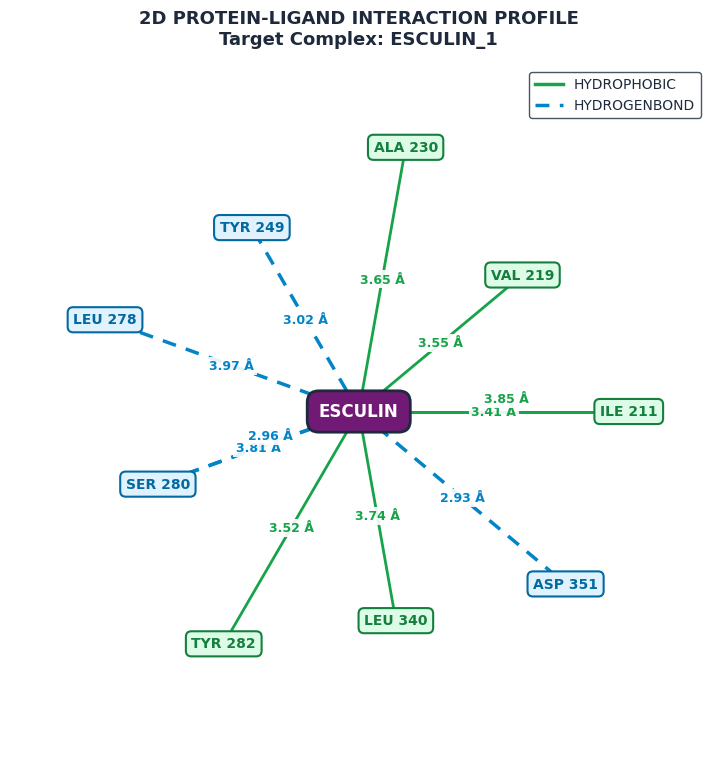

In [28]:
#@title CELL 11.5: 2D Protein-Ligand Interaction Network Mapping { display-mode: "form" }
#@markdown Generate an elegant, publication-ready schematic network map matching commercial molecular modeling software aesthetics.

Target_pose_ID = "ESCULIN_1" #@param {type:"string"}
Canvas_Style = "White Studio" #@param ["White Studio", "Dark Mode"]
Show_Distance_Labels = True #@param {type:"boolean"}

import os
import math
import pandas as pd
import matplotlib.pyplot as plt

# Retrieve absolute directory pathways from environmental memory
INT_FLD = os.environ.get('INT_FLD')
if not INT_FLD:
    raise ValueError("Workspace pathways missing. Please re-run Cell 3 first.")

interactions_csv = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_interactions.csv")

print(f"[-] Locating structural interaction records for: {Target_pose_ID.upper()}")

if not os.path.exists(interactions_csv):
    print(f"[!] Error: No interaction CSV file found for '{Target_pose_ID.upper()}'.")
    print("    ↳ Action required: Make sure you run CELL 10 first to extract the bonds.")
else:
    df = pd.read_csv(interactions_csv)
    if df.empty:
        print(f"[!] Map Alert: The interaction matrix for '{Target_pose_ID.upper()}' is completely empty.")
    else:
        print(f"[+] Rebuilding 2D layout engine for high-resolution publication export...")
        df["RES_LABEL"] = df["RESTYPE"].str.strip() + " " + df["RESNR"].astype(str)

        # Software-matching color palette dictionary definitions
        color_palette = {
            "HYDROGENBOND": {"line": "#0284C7", "box_fill": "#E0F2FE", "box_edge": "#0369A1", "text": "#0369A1"},
            "HYDROPHOBIC":  {"line": "#16A34A", "box_fill": "#DCFCE7", "box_edge": "#15803D", "text": "#15803D"},
            "SALTBRIDGE":   {"line": "#EA580C", "box_fill": "#FFEDD5", "box_edge": "#C2410C", "text": "#C2410C"},
            "PI-STACKING":  {"line": "#9333EA", "box_fill": "#F3E8FF", "box_edge": "#7E22CE", "text": "#7E22CE"}
        }

        if Canvas_Style == "Dark Mode":
            bg_color, text_color, card_bg = "#121212", "#FFFFFF", "#1E1E1E"
            ligand_fill, ligand_text = "#4A044E", "#FDF4FF"
        else:
            bg_color, text_color, card_bg = "#FFFFFF", "#1E293B", "#F8FAFC"
            ligand_fill, ligand_text = "#701A75", "#FFFFFF"

        fig, ax = plt.subplots(figsize=(9, 9), facecolor=bg_color)
        ax.set_facecolor(bg_color)

        ligand_x, ligand_y = 0.0, 0.0
        unique_residues = df["RES_LABEL"].unique().tolist()
        num_residues = len(unique_residues)

        residue_coords = {}
        for idx, res in enumerate(unique_residues):
            # Alternating radial layout to eliminate crowding completely
            current_radius = 4.8 if idx % 2 == 0 else 3.8
            angle = (2 * math.pi * idx) / num_residues
            rx = current_radius * math.cos(angle)
            ry = current_radius * math.sin(angle)
            residue_coords[res] = (rx, ry)

        # Step 1: Draw high-contrast non-covalent vector lines
        bond_counters = {}
        for _, row in df.iterrows():
            res = row["RES_LABEL"]
            rx, ry = residue_coords[res]
            bond_type = row["BOND"]
            distance = row["DIST_CALC"]
            b_cfg = color_palette.get(bond_type, {"line": "#64748B"})

            if bond_type == "HYDROGENBOND":
                linestyle = (0, (4, 3))
                linewidth = 2.5
            elif bond_type == "HYDROPHOBIC":
                linestyle = "solid"
                linewidth = 2.0
            elif bond_type == "SALTBRIDGE":
                linestyle = (0, (6, 2, 1, 2))
                linewidth = 3.0
            else:
                linestyle = "dotted"
                linewidth = 2.5

            ax.plot([ligand_x, rx], [ligand_y, ry], color=b_cfg["line"], linestyle=linestyle, linewidth=linewidth, zorder=1)

            if Show_Distance_Labels:
                mx = (ligand_x + rx) / 2.0
                my = (ligand_y + ry) / 2.0
                bond_counters[res] = bond_counters.get(res, 0) + 1
                if bond_counters[res] > 1:
                    mx += 0.22 * (bond_counters[res] - 1)
                    my += 0.22 * (bond_counters[res] - 1)
                ax.text(mx, my, f"{distance} Å", color=b_cfg["line"], fontsize=9, fontweight="bold",
                        bbox=dict(boxstyle="square,pad=0.2", facecolor=bg_color, edgecolor="none", alpha=0.9),
                        ha="center", va="center", zorder=3)

        # Step 2: Draw dynamic rounded residue cards
        for res, (rx, ry) in residue_coords.items():
            res_df = df[df["RES_LABEL"] == res]
            primary_bond = res_df["BOND"].iloc[0]
            b_cfg = color_palette.get(primary_bond, {"box_fill": "#F1F5F9", "box_edge": "#94A3B8", "text": "#475569"})
            ax.text(rx, ry, res, color=b_cfg["text"], fontsize=10, fontweight="bold",
                    ha="center", va="center", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.4", facecolor=b_cfg["box_fill"], edgecolor=b_cfg["box_edge"], linewidth=1.5))

        # Step 3: Draw central ligand structural hub panel
        lig_hub_label = Target_pose_ID.split('_')[0].upper()
        ax.text(ligand_x, ligand_y, lig_hub_label, color=ligand_text, fontsize=12, fontweight="bold",
                ha="center", va="center", zorder=5,
                bbox=dict(boxstyle="round,pad=0.7", facecolor=ligand_fill, edgecolor=text_color, linewidth=2.0))

        ax.set_xlim(-6.2, 6.2)
        ax.set_ylim(-6.2, 6.2)
        ax.axis("off")

        # Compact and safe Legend Drawing Sub-engine
        legend_elements = []
        active_bonds = list(df["BOND"].unique())
        for b_name in active_bonds:
            if b_name in color_palette:
                b_cfg = color_palette[b_name]
                b_style = (0, (4, 3)) if b_name == "HYDROGENBOND" else "solid" if b_name == "HYDROPHOBIC" else (0, (6, 2, 1, 2)) if b_name == "SALTBRIDGE" else "dotted"
                legend_elements.append(plt.Line2D([0], [0], color=b_cfg["line"], linestyle=b_style, lw=2.5, label=b_name))

        ax.legend(handles=legend_elements, loc="upper right", frameon=True, facecolor=bg_color, edgecolor=text_color, labelcolor=text_color, fontsize=10)

        plt.title(f"2D PROTEIN-LIGAND INTERACTION PROFILE\nTarget Complex: {Target_pose_ID.upper()}", color=text_color, fontsize=13, fontweight="bold", pad=15)

        output_png_path = os.path.join(INT_FLD, f"{Target_pose_ID.upper()}_2D_interaction.png")
        plt.savefig(output_png_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

        print(f"[+] Production-grade schematic compiled successfully.")
        print(f"    ↳ Saved 2D graphic -> {output_png_path}\n")
        plt.show()

In [29]:
#@title CELL 12: Permanent Cloud Archiving & Export { display-mode: "form" }
#@markdown Securely package and back up your complete virtual screening and interaction profile workspace.

Export_Target_Channel = "Local Download via Browser" #@param ["Export to Mounted Google Drive", "Local Download via Browser"]

import os
import shutil

# Retrieve absolute directory pathways from environmental memory set in Cell 3
WRK_DIR = os.environ.get('WRK_DIR')
if not WRK_DIR:
    raise ValueError("Active project workspace root not discovered. Please run Cell 3 first to map paths.")

job_id_string = os.path.basename(WRK_DIR)
archive_output_name = f"{job_id_string}_final_export"
archive_local_path = os.path.join(os.getcwd(), archive_output_name)

print(f"[-] Compressing workspace tree node elements for project: [{job_id_string}]")

# Compress the entire project root directory folder recursively into a unified .zip archive
shutil.make_archive(archive_local_path, 'zip', WRK_DIR)
zip_file_complete = f"{archive_local_path}.zip"

print(f"    ↳ Archive compilation complete: {os.path.basename(zip_file_complete)}")

# --- ROUTE A: Secure Mount & Transfer to Personal Google Cloud Storage ---
if Export_Target_Channel == "Export to Mounted Google Drive":
    print("[-] Activating Google Drive authentication pathways...")
    try:
        from google.colab import drive
        # Triggers secure handshake loop inside the Colab platform workspace
        drive.mount('/content/drive', force_remount=True)

        gdrive_destination_folder = "/content/drive/MyDrive/Nanomed_Docking_Results"
        os.makedirs(gdrive_destination_folder, exist_ok=True)

        gdrive_target_path = os.path.join(gdrive_destination_folder, f"{archive_output_name}.zip")
        shutil.copy(zip_file_complete, gdrive_target_path)

        print("\n[+] CLOUD PERSISTENCE ARCHIVING COMPLETE")
        print(f"    ↳ Target File Synchronized -> {gdrive_target_path}")
        print("    ↳ Status: Securely saved inside your personal Google Drive storage node folder.")
    except Exception as e:
        print(f"\n[!] Cloud Link Failure: {e}")
        print("    ↳ Fallback action: Defaulting back to native browser storage pipeline...")
        Export_Target_Channel = "Local Download via Browser"

# --- ROUTE B: Native Direct Browser File Stream Extraction ---
if Export_Target_Channel == "Local Download via Browser":
    print("[-] Initializing secure browser download streaming channels...")
    try:
        from google.colab import files
        print("\n[+] CLICK PROMPT TRIGGER DOWNSTREAM REACHED")
        print("    ↳ Your browser will now prompt you to save the compiled ZIP dataset archive.")
        files.download(zip_file_complete)
    except Exception as e:
        print(f"\n[!] Browser Stream Error: {e}")
        print(f"    ↳ Action required: Manually right-click the file in the file explorer and download: {zip_file_complete}")

[-] Compressing workspace tree node elements for project: [TGFb_1PY5_VS]
    ↳ Archive compilation complete: TGFb_1PY5_VS_final_export.zip
[-] Initializing secure browser download streaming channels...

[+] CLICK PROMPT TRIGGER DOWNSTREAM REACHED
    ↳ Your browser will now prompt you to save the compiled ZIP dataset archive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>